In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6" "pmdarima==2.1.1"

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 0 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))


def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

print("사용 폰트:", FONT)

사용 폰트: DejaVu Sans


In [2]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일 패널에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요

raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다

_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
_y = _y.fillna(_y.shift(-24 * 7))         # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
df["demand"] = _y                         # 보정 수요 — 모형 학습이 쓸 열 (원본 시간 계열 count 는 그대로)
df["is_imputed"] = df["functioning"].eq("No")

daily_c = df["count"].resample("D").sum()   # 쓸 변수 — 원본 시간 계열의 하루 합계로 집계한 일 수요

try:                                        # auto_arima 를 불러온다 — 없으면 같은 이름의 대체를 준비한다
    from pmdarima import auto_arima
    _search_backend = "pmdarima.auto_arima"
except Exception:
    import subprocess
    import sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pmdarima==2.1.1"], check=False)
    try:
        from pmdarima import auto_arima
        _search_backend = "pmdarima.auto_arima (이 셀에서 설치)"
    except Exception:
        auto_arima = auto_arima_like          # 대체 탐색 — 정의는 맨 위 [채점] 셀에 있습니다
        _search_backend = "auto_arima_like (statsmodels 로 만든 대체)"

print(f"행 x 열 : {df.shape[0]:,} x {df.shape[1]}   기간 {df.index.min()} ~ {df.index.max()}")
print(f"원본 시간 계열 count 평균 {df['count'].mean():.4f} 대/시간  →  "
      f"보정 수요 demand 평균 {df['demand'].mean():.4f} 대/시간")
print(f"휴무 {int(df['is_imputed'].sum())}시간 / "
      f"{df.index[df['is_imputed']].normalize().nunique()}일   "
      f"보정 수요 결측 {int(df['demand'].isna().sum())}건")
print(f"일 수요 {len(daily_c)}일   평균 {daily_c.mean():,.1f} 대/일")
print(f"그중 시스템이 정지해 하루 합계가 0 인 날 {int((daily_c == 0).sum())}일   "
      f"탐색과 검정은 원본 시간 계열로 한다는 첫날의 약속을 따른 결과입니다")
print(f"auto_arima 구현 : {_search_backend}")
if "auto_arima_like" in _search_backend:
    print("ⓘ 대체 탐색은 pmdarima 와 다른 차수를 골라 AIC 가 달라집니다 — 채점은 AIC 칸을 보지 않습니다")
print("쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 시간 계열, 대)"
      " · daily_c (하루 합계 일 수요, 대/일)"
      " · auto_arima (차수를 자동으로 고르는 함수)")

행 x 열 : 8,760 x 16   기간 2017-12-01 00:00:00 ~ 2018-11-30 23:00:00
원본 시간 계열 count 평균 704.6021 대/시간  →  보정 수요 demand 평균 737.8491 대/시간
휴무 295시간 / 13일   보정 수요 결측 0건
일 수요 365일   평균 16,910.4 대/일
그중 시스템이 정지해 하루 합계가 0 인 날 12일   탐색과 검정은 원본 시간 계열로 한다는 첫날의 약속을 따른 결과입니다
auto_arima 구현 : pmdarima.auto_arima
쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 시간 계열, 대) · daily_c (하루 합계 일 수요, 대/일) · auto_arima (차수를 자동으로 고르는 함수)


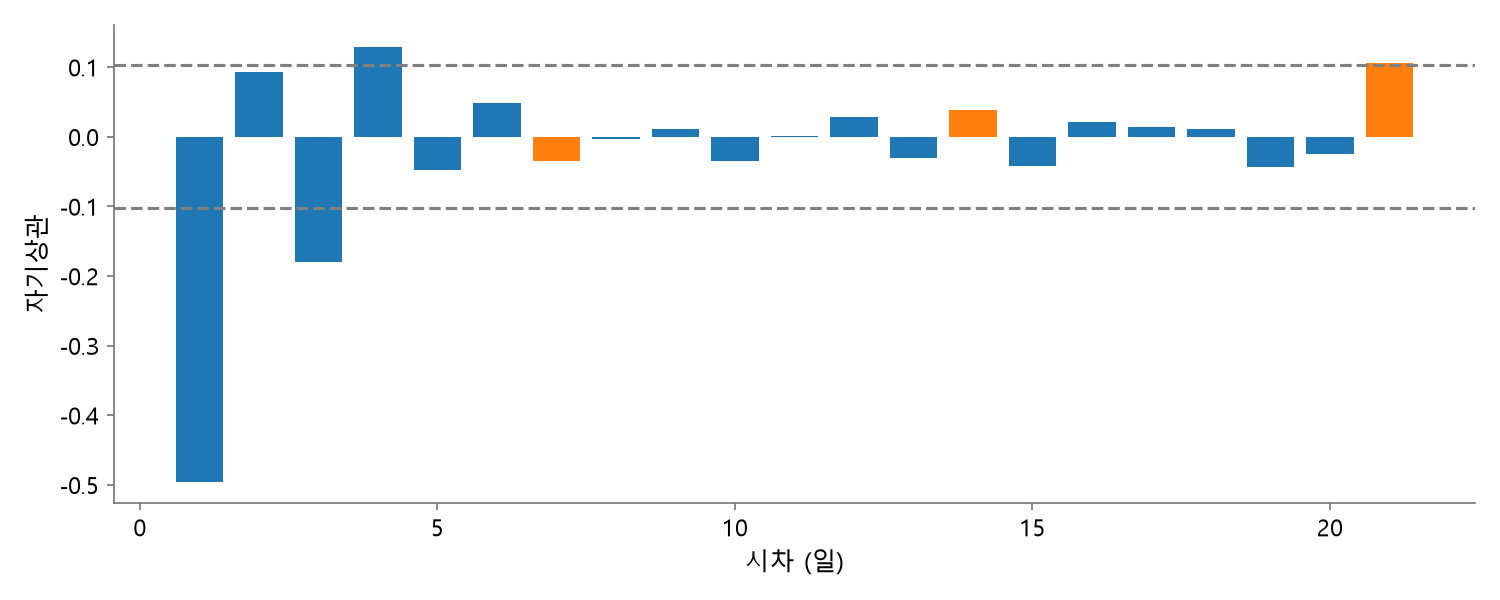

하루 합계 계열 d: 1
하루 합계 계열 AIC: 7460.94
참고 order (1, 1, 3) seasonal_order None 경계선 0.1027 acf7 -0.0352 acf14 0.038 acf21 0.1059


In [4]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
배차팀에서 168시간을 하루 합계 365일 계열로 대신할 수 있는지 질문이 왔어.
아래 변수들은 그대로 유지하고 코드에 반영해줘(필수!)
daily_c: 일 수요
auto_arima: 차수를 자동으로 고르는 함수
df, df['count']: 시간당 기록 표 전체와 원본 시간 계열
acf: 시차별 자기상관을 한 번에 반환하는 함수

1. 하루 합계 계열 1차 차분 횟수 d: 단위 횟수, 정수, ARIMA(p, d, q)에서 d의 값
2. 하루 합계 계열 AIC: 단위 없는 점수, 소수점 아래 2자리 해당 모형의 AIC
3. 그래프(가로축은 시차 1일부터 21일까지, 세로축은 자기상관인 막대 그래프)
대상 계열: daily_c에서 하루 전 값을 뺀 계열(1차 차분 1회)
막대: 시차 1부터 21까지 21개
색: 요일에 해당하는 시차 7, 14, 21만 다른 색 지정
가로 점선: 경계선 +-196/루트 T를 가로축 전체에 걸쳐 위 아래 하나씩 총 2개
경계선: 자기상관이 0과 구별되는지 판단하는 기준선 T는 그 계열의 자료 수
가로축 이름: 시차 (일)
세로축 이름: 자기상관
4. 참고 행: 탐색이 고른 차수와 계절 차수, 경계선, 시차 7, 14, 21의 자기상관을 등호 없이 기재

해당 코드에선 계절 차수를 고르지 않음. -> seasonal=false

"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

diff = daily_c.diff().dropna()
T = len(diff)

model = auto_arima(daily_c, seasonal=False, suppress_warnings=True)
p, d, q = model.order
aic = round(model.aic(), 2)

lags = np.arange(1, 22)
acf_vals = acf(diff, nlags=21)[1:22]
bound = 1.96 / np.sqrt(T)

colors = ['tab:orange' if lag in (7, 14, 21) else 'tab:blue' for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, acf_vals, color=colors)
ax.axhline(bound, linestyle='--', color='gray')
ax.axhline(-bound, linestyle='--', color='gray')
ax.set_xlabel('시차 (일)')
ax.set_ylabel('자기상관')
plt.show()

print("하루 합계 계열 d:", d)
print("하루 합계 계열 AIC:", aic)

seasonal_order = getattr(model, 'seasonal_order_', None)
print("참고", "order", model.order, "seasonal_order", seasonal_order,
      "경계선", round(bound, 4),
      "acf7", round(acf_vals[6], 4),
      "acf14", round(acf_vals[13], 4),
      "acf21", round(acf_vals[20], 4))

In [5]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals() or "demand" not in df.columns:   # 이 미션만 따로 열어도 단독으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일 패널에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다
    _s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
    _y = _s.fillna(_s.shift(24 * 7))      # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
    df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
    df["is_imputed"] = df["functioning"].eq("No")

FIT_START, TRAIN_END = "2018-09-01 00:00", "2018-11-16 23:00"
y_train = df["demand"].loc[FIT_START:TRAIN_END]   # 쓸 변수 — 학습 구간의 보정 수요 (대/시간)

D_LEVEL, D_SEASONAL, M = 0, 1, 24         # 차분 조건 — 첫날의 검정과 계절성 강도가 정한 값 3개
P_GRID, Q_GRID = [0, 1, 2], [0, 1]        # 비계절 자기회귀·이동평균 후보
FIT_OPTS = "trend=None, enforce_stationarity=True, enforce_invertibility=True"

print(f"학습 구간 {FIT_START} ~ {TRAIN_END}   {len(y_train):,}시간   "
      f"채운 시각 {int(df['is_imputed'].loc[FIT_START:TRAIN_END].sum())}시간")
print(f"학습 평균 {y_train.mean():,.1f} 대/시간   결측 {int(y_train.isna().sum())}건")
print(f"차분 조건 고정 — 1차 차분 횟수 d = {D_LEVEL} · 계절차분 D = {D_SEASONAL} · 계절 주기 m = {M}")
print(f"계절 차수 고정 — (0, {D_SEASONAL}, 0, {M})   오늘 비교하는 것은 p 와 q 뿐입니다")
print(f"후보 격자 — p {P_GRID} x q {Q_GRID}   조합 {len(P_GRID) * len(Q_GRID)}개")
print(f"적합 옵션 통일 — {FIT_OPTS}")
print("여섯 조합을 모두 적합하는 데 1분이 채 걸리지 않습니다.")
print("쓸 수 있는 이름 : y_train (학습 구간 보정 수요, 대/시간) · D_LEVEL · D_SEASONAL · M"
      " (차분 조건 값 3개) · P_GRID (비계절 p 후보) · Q_GRID (비계절 q 후보)"
      " · FIT_OPTS (적합 옵션 문자열)")

학습 구간 2018-09-01 00:00 ~ 2018-11-16 23:00   1,848시간   채운 시각 247시간
학습 평균 986.6 대/시간   결측 0건
차분 조건 고정 — 1차 차분 횟수 d = 0 · 계절차분 D = 1 · 계절 주기 m = 24
계절 차수 고정 — (0, 1, 0, 24)   오늘 비교하는 것은 p 와 q 뿐입니다
후보 격자 — p [0, 1, 2] x q [0, 1]   조합 6개
적합 옵션 통일 — trend=None, enforce_stationarity=True, enforce_invertibility=True
여섯 조합을 모두 적합하는 데 1분이 채 걸리지 않습니다.
쓸 수 있는 이름 : y_train (학습 구간 보정 수요, 대/시간) · D_LEVEL · D_SEASONAL · M (차분 조건 값 3개) · P_GRID (비계절 p 후보) · Q_GRID (비계절 q 후보) · FIT_OPTS (적합 옵션 문자열)


 p  q      AIC
 2  1 25217.34
 2  0 25342.73
 1  1 25368.86
 0  1 25380.54
 1  0 25398.75
 0  0 25439.37
공식 차수 = (2,1,1)(0,1,0,24)
공식 차수 AIC = 25,217.34
1위와 2위의 AIC 차이 = 125.40


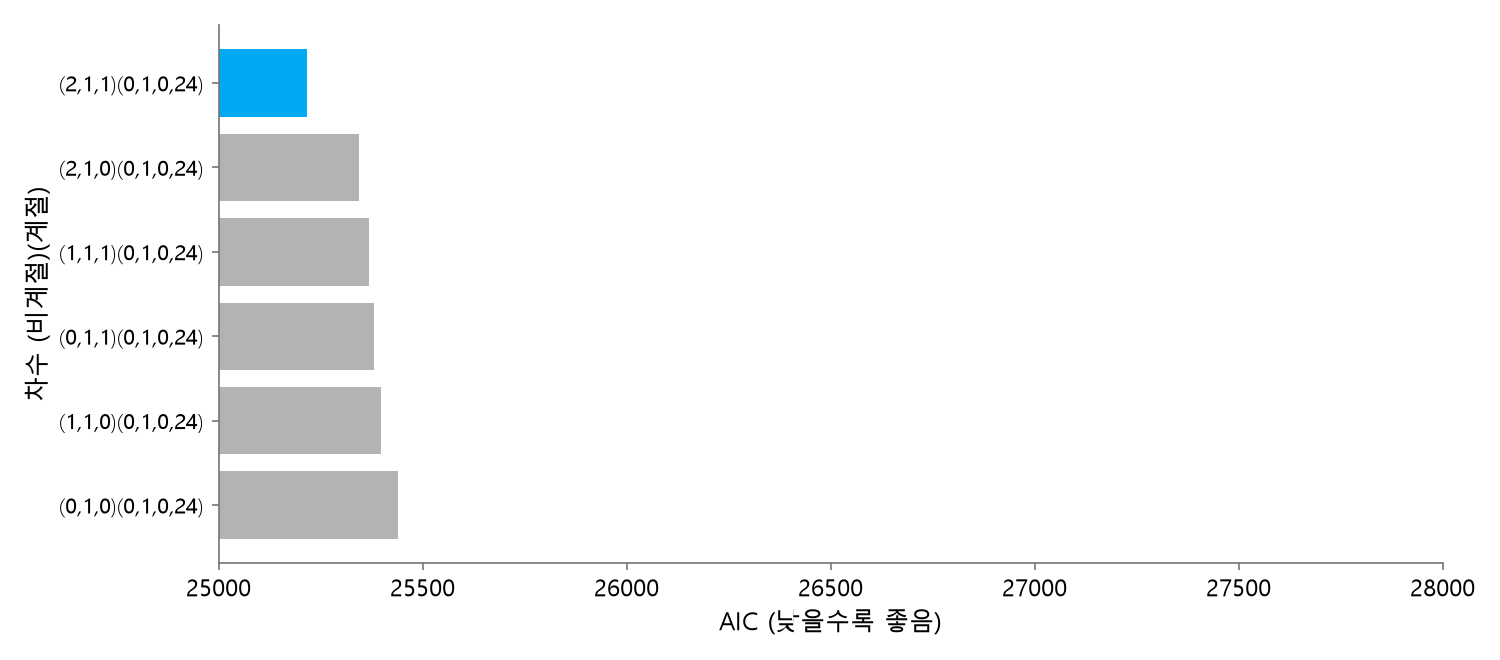

In [6]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
PROMPT = """

"""
# --- 여기부터 AI 코드 ---
# ↓ 전임 담당자의 코드 — 그대로 실행하면 채점이 ❌ 를 냅니다
rows = []
for p, q in itertools.product(P_GRID, Q_GRID):
    _r = SARIMAX(y_train, order=(p, 1, q), seasonal_order=(0, D_SEASONAL, 0, M),
                 trend=None, enforce_stationarity=True,
                 enforce_invertibility=True).fit(disp=False)
    rows.append({"p": p, "q": q, "AIC": _r.aic})

grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
best = grid.iloc[0]
second = grid.iloc[1]
print(grid.round(2).to_string(index=False))
print(f"공식 차수 = ({int(best.p)},1,{int(best.q)})(0,{D_SEASONAL},0,{M})")
print(f"공식 차수 AIC = {best.AIC:,.2f}")
print(f"1위와 2위의 AIC 차이 = {second.AIC - best.AIC:,.2f}")

labels = [f"({int(r.p)},1,{int(r.q)})(0,{D_SEASONAL},0,{M})" for r in grid.itertuples()]
colors = [COL["하늘색"] if i == 0 else COL["연회색"] for i in range(len(grid))]
fig, ax = plt.subplots(figsize=(FIG_W, 4.4))
ax.barh(range(len(grid) - 1, -1, -1), grid["AIC"], color=colors)
ax.set_yticks(range(len(grid) - 1, -1, -1))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(25000, 28000)
ax.set_xlabel("AIC (낮을수록 좋음)")
ax.set_ylabel("차수 (비계절)(계절)")
plt.show()

 p  q      AIC
 1  1 25209.34
 2  1 25211.16
 2  0 25223.65
 1  0 25327.20
 0  1 26294.07
 0  0 27820.29
공식 차수 = (1,0,1)(0,1,0,24)
공식 차수 AIC = 25,209.34
1위와 2위의 AIC 차이 = 1.83


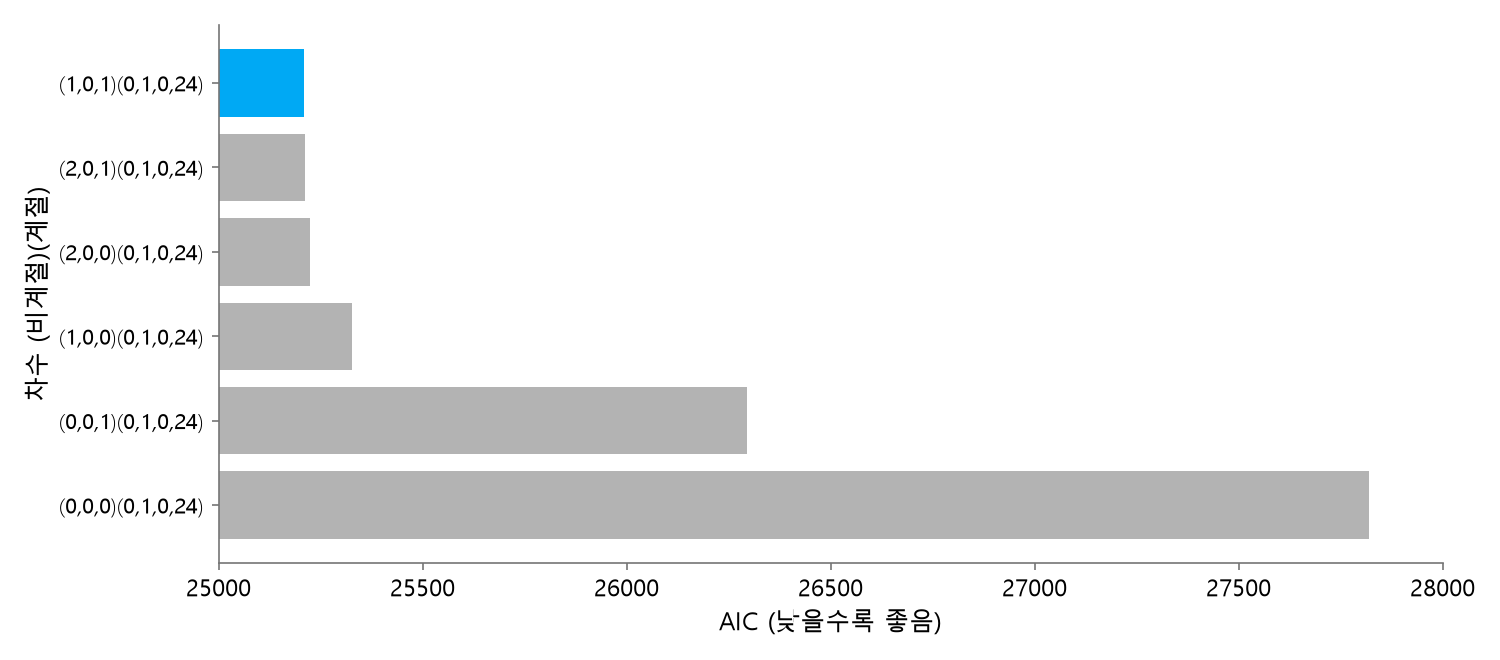

In [7]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
PROMPT = """
변수들은 그대로 유지한채 전임 담당자의 코딩에서 틀린 부분을 수정해줘

1. 공식 차수 AIC: 단위 없은 점수, 소수점 아래 2자리, AIC가 가장 낮은 조합의 AIC
전임 담당자의 코드에서 차분 조건이 1로 고정되어 있는데 준비 셀에 있는 차수로 수정해야해
2. 1위와 2위의 AIC 차이: 단위 없는 점수, 소수점 아래 2자리, AIC가 가장 낮은 조합과 그 다음 조합의 AIC
3. 그래프: 가로축은 AIC, 세로축은 차수 레벨 6개인 가로 막대 그래프
막대: 후보 6개 조합에 하나씩
가로축 이름: AIC (낮을수록 좋음), 세로축 이름: 차수 (비계절)(계절)
세로 눈금: 조합마다 차수 레벨 하나
AIC가 가장 낮은 것으 위로오게 정렬, 가장 낮은 막내는 색상 다르게 설정
가로축 범위 25_000~28_000까지
"""
# --- 여기부터 AI 코드 ---
rows = []
for p, q in itertools.product(P_GRID, Q_GRID):
    _r = SARIMAX(y_train, order=(p, D_LEVEL, q), seasonal_order=(0, D_SEASONAL, 0, M),
                 trend=None, enforce_stationarity=True,
                 enforce_invertibility=True).fit(disp=False)
    rows.append({"p": p, "q": q, "AIC": _r.aic})

grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
best = grid.iloc[0]
second = grid.iloc[1]
print(grid.round(2).to_string(index=False))
print(f"공식 차수 = ({int(best.p)},{D_LEVEL},{int(best.q)})(0,{D_SEASONAL},0,{M})")
print(f"공식 차수 AIC = {best.AIC:,.2f}")
print(f"1위와 2위의 AIC 차이 = {second.AIC - best.AIC:,.2f}")

labels = [f"({int(r.p)},{D_LEVEL},{int(r.q)})(0,{D_SEASONAL},0,{M})" for r in grid.itertuples()]
colors = [COL["하늘색"] if i == 0 else COL["연회색"] for i in range(len(grid))]
fig, ax = plt.subplots(figsize=(FIG_W, 4.4))
ax.barh(range(len(grid) - 1, -1, -1), grid["AIC"], color=colors)
ax.set_yticks(range(len(grid) - 1, -1, -1))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(25000, 28000)
ax.set_xlabel("AIC (낮을수록 좋음)")
ax.set_ylabel("차수 (비계절)(계절)")
plt.show()